In [2]:
import pandas as pd
import io
import numpy as np
from google.colab import files

# Step 1: Trigger the upload widget
uploaded = files.upload()

# Step 2: Load the data into a DataFrame
# Note: Ensure the file you upload is named 'credit_risk_dataset.csv'
df = pd.read_csv(io.BytesIO(uploaded['credit_risk_dataset.csv']))

print("Dataset successfully loaded. Data Shape:", df.shape)
df.head()

Saving credit_risk_dataset.csv to credit_risk_dataset.csv
Dataset successfully loaded. Data Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
# Handle missing values in Tenure (Employment Length)
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)

# Drop any remaining rows with null values to maintain data integrity
df = df.dropna()

# Select HR-centric features: Age, Annual Salary, Tenure, and Requested Loan Amount
# Target (y): loan_status (0 = Reliable/Approved, 1 = Risk/Default)
X = df[['person_age', 'person_income', 'person_emp_length', 'loan_amnt']]
y = df['loan_status']

print("Features selected for Scoring: Age, Income, Tenure, and Loan Amount.")

Features selected for Scoring: Age, Income, Tenure, and Loan Amount.


/tmp/ipykernel_540/2180419833.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split: 80% for training the 'Scorecard', 20% for validating accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

print("HR Credit Scoring Model trained successfully.")

HR Credit Scoring Model trained successfully.


Overall Model Accuracy: 79.37%

--- HR Credit Scoring Report ---
              precision    recall  f1-score   support

    Reliable       0.80      0.99      0.88      4585
        Risk       0.74      0.11      0.19      1308

    accuracy                           0.79      5893
   macro avg       0.77      0.55      0.54      5893
weighted avg       0.78      0.79      0.73      5893



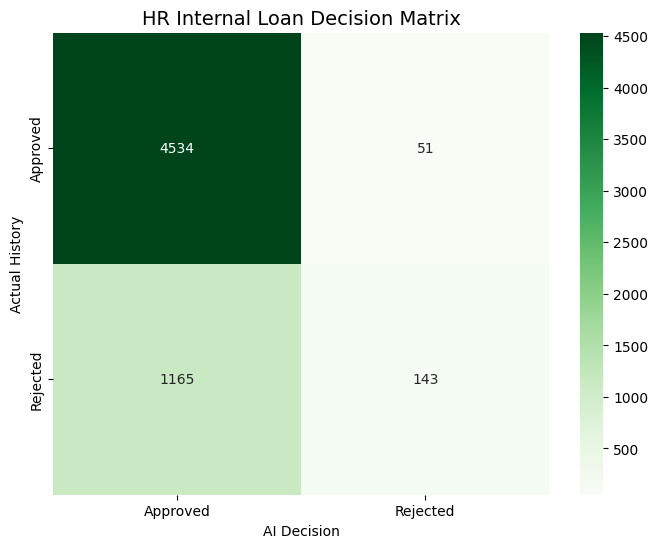

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = lr_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy:.2%}")

# Print Classification Report for Precision/Recall
print("\n--- HR Credit Scoring Report ---")
print(classification_report(y_test, y_pred, target_names=['Reliable', 'Risk']))

# Visualize the Results with a Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Approved', 'Rejected'],
            yticklabels=['Approved', 'Rejected'])
plt.title('HR Internal Loan Decision Matrix', fontsize=14)
plt.xlabel('AI Decision')
plt.ylabel('Actual History')
plt.savefig('Credit_Scoring_Confusion_Matrix.png', dpi=300)
plt.show()

In [6]:
# Input Format: [Age, Annual Salary, Tenure (Years), Loan Amount Requested]
# Example: 30 years old, 60k salary, 5 years tenure, asking for 5k loan
new_employee_data = np.array([[30, 60000, 5, 5000]])

# Calculate the probability of risk
risk_prob = lr_model.predict_proba(new_employee_data)[0][1]
final_decision = lr_model.predict(new_employee_data)

print(f"Employee Loan Risk Probability: {risk_prob:.2%}")

if final_decision[0] == 0:
    print("AI Recommendation: APPROVE - This employee meets reliability thresholds.")
else:
    print("AI Recommendation: REVIEW - High default risk detected based on peer history.")

Employee Loan Risk Probability: 12.17%
AI Recommendation: APPROVE - This employee meets reliability thresholds.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


/tmp/ipykernel_540/2199681229.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_importance, palette='viridis')


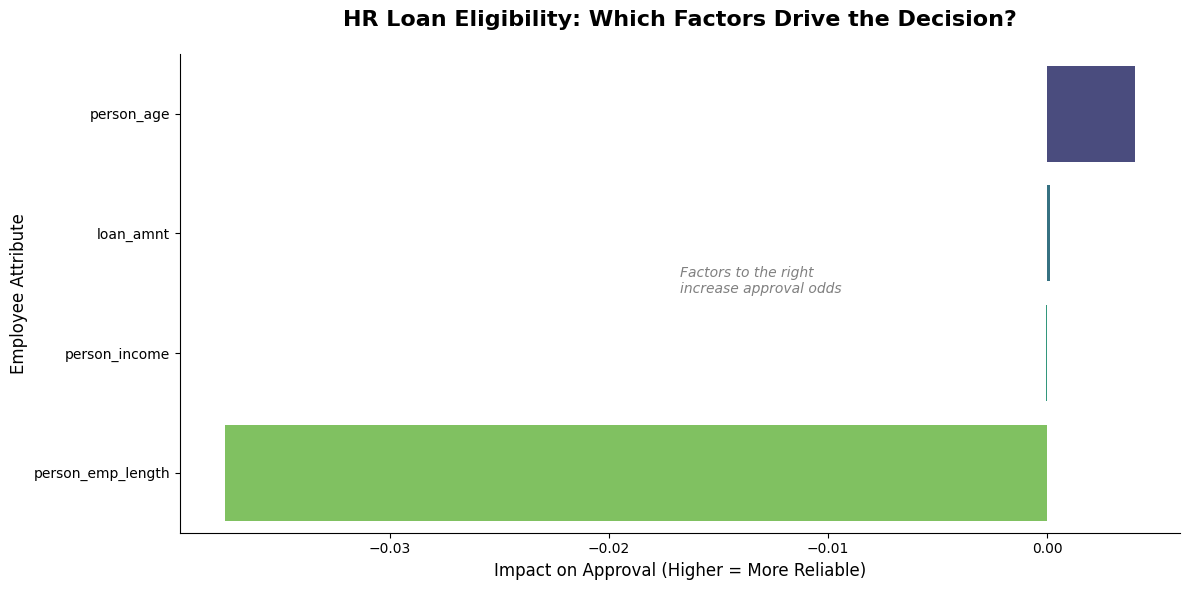

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the importance (coefficients) from the Logistic Regression model
importance = lr_model.coef_[0]
feature_names = X.columns

# 2. Create a DataFrame for easy plotting
feat_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feat_importance = feat_importance.sort_values(by='Importance', ascending=False)

# 3. Plotting
plt.figure(figsize=(12, 6))
# Using a 'coolwarm' palette: Blue for positive impact, Red for negative
sns.barplot(x='Importance', y='Feature', data=feat_importance, palette='viridis')

# 4. Styling for HR Reports
plt.title('HR Loan Eligibility: Which Factors Drive the Decision?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Impact on Approval (Higher = More Reliable)', fontsize=12)
plt.ylabel('Employee Attribute', fontsize=12)
sns.despine()

# 5. Add a clear explanation label
plt.annotate('Factors to the right\nincrease approval odds', xy=(0.5, 0.5), xycoords='axes fraction',
             fontsize=10, color='gray', style='italic')

plt.tight_layout()
plt.savefig('HR_Feature_Importance.png', dpi=300)
plt.show()